# Social Network Analysis Using NetworkX
    Supports: CSV, EdgeList, GML, Pajek (.net), GraphML, GEXF
    Datasets: Facebook, Karate Club, and other real-world networks

##WHAT IS A SOCIAL NETWORK DATASET?

    A social network dataset represents relationships (edges) between
    entities (nodes). Examples:
    - People connected by friendships
    - Users interacting on social media
    - Proteins interacting in biology

        Each dataset is modeled as a graph G = (V, E)
        V = set of nodes
        E = set of edges

          This script performs:
          - Graph loading
          - Visualization
          - Degree distribution
          - Density
          - Clustering coefficient
          - Diameter

**STEP 1: Import Required Libraries**

In [5]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

**STEP 1.5: List Built-in Datasets Available in NetworkX**

In [6]:
# NetworkX provides several built-in graph generators and example datasets


print("Some Built-in Graphs in NetworkX:")
print("1. Karate Club Graph -> nx.karate_club_graph()")
print("2. Florentine Families -> nx.florentine_families_graph()")
print("3. Davis Southern Women -> nx.davis_southern_women_graph()")
print("4. Les Miserables -> nx.les_miserables_graph()")
print("5. Random Graphs -> nx.erdos_renyi_graph(n,p)")
print("6. Watts-Strogatz Small World -> nx.watts_strogatz_graph(n,k,p)")
print("7. Barabasi-Albert Scale-Free -> nx.barabasi_albert_graph(n,m)")


# Example: Load Karate Club dataset

Some Built-in Graphs in NetworkX:
1. Karate Club Graph -> nx.karate_club_graph()
2. Florentine Families -> nx.florentine_families_graph()
3. Davis Southern Women -> nx.davis_southern_women_graph()
4. Les Miserables -> nx.les_miserables_graph()
5. Random Graphs -> nx.erdos_renyi_graph(n,p)
6. Watts-Strogatz Small World -> nx.watts_strogatz_graph(n,k,p)
7. Barabasi-Albert Scale-Free -> nx.barabasi_albert_graph(n,m)


**STEP 2: Load Built-in Karate Club Dataset**

In [7]:
karate_graph = nx.karate_club_graph()
print("Karate Club Graph Loaded")

Karate Club Graph Loaded


**STEP 3: Functions to Load Different Dataset Formats**

In [8]:
# Edge list (txt or csv)
def load_edgelist(path):
    return nx.read_edgelist(path)

# CSV file with columns: source,target
def load_csv(path):
    df = pd.read_csv(path)
    return nx.from_pandas_edgelist(df, source='source', target='target')

# GML
def load_gml(path):
    return nx.read_gml(path)

# Pajek (.net)
def load_pajek(path):
    return nx.read_pajek(path)

# GraphML
def load_graphml(path):
    return nx.read_graphml(path)

# GEXF
def load_gexf(path):
    return nx.read_gexf(path)

**STEP 4: Create Graph Object**

In [9]:
G = karate_graph

# Directed Graph Example
DG = nx.DiGraph(G)

**STEP 5: Visualize Graph (Circular Layout)**

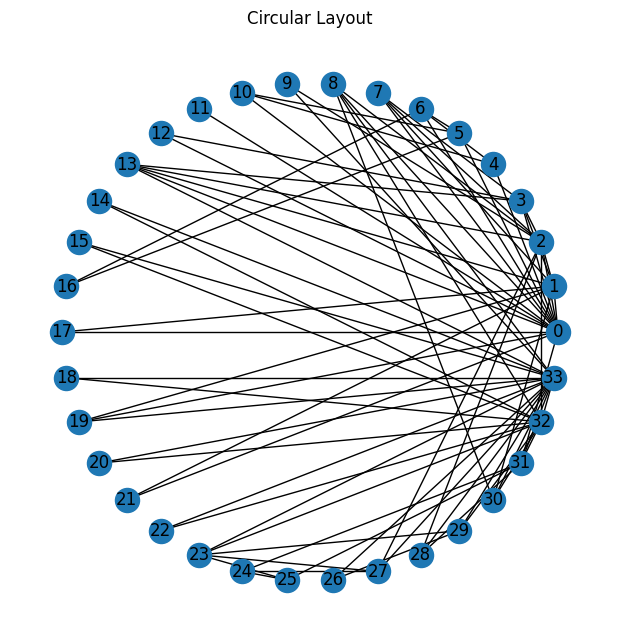

In [10]:
plt.figure(figsize=(6,6))
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_size=300)
plt.title("Circular Layout")
plt.show()

**STEP 6: Degree of Nodes**

    Degree Formula:
        deg(v) = number of edges connected to node v

In [11]:
# Dictionary: {node:degree}
degree_dict = dict(G.degree())
print("Degree Dictionary:\n", degree_dict)

# Set of unique degrees
unique_degrees = set(degree_dict.values())
print("Unique Degrees:", unique_degrees)

Degree Dictionary:
 {0: 16, 1: 9, 2: 10, 3: 6, 4: 3, 5: 4, 6: 4, 7: 4, 8: 5, 9: 2, 10: 3, 11: 1, 12: 2, 13: 5, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 3, 20: 2, 21: 2, 22: 2, 23: 5, 24: 3, 25: 3, 26: 2, 27: 4, 28: 3, 29: 4, 30: 4, 31: 6, 32: 12, 33: 17}
Unique Degrees: {1, 2, 3, 4, 5, 6, 9, 10, 12, 16, 17}


**STEP 7: Degree Distribution**

    Count of each degree
        P(k) = number of nodes with degree k

In [12]:
degree_counts = Counter(degree_dict.values())
print("Degree Counts:", degree_counts)

# Convert to lists
k = list(degree_counts.keys())
v = list(degree_counts.values())

Degree Counts: Counter({2: 11, 3: 6, 4: 6, 5: 3, 6: 2, 16: 1, 9: 1, 10: 1, 1: 1, 12: 1, 17: 1})


**STEP 8: Plot Degree Distribution (Bar)**

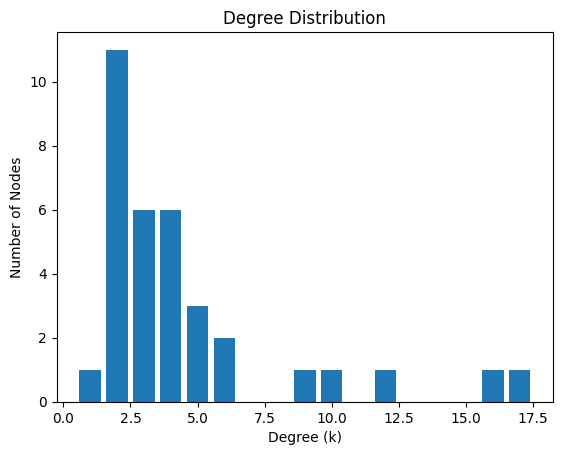

In [13]:
plt.figure()
plt.bar(k, v)
plt.xlabel("Degree (k)")
plt.ylabel("Number of Nodes")
plt.title("Degree Distribution")
plt.show()

**STEP 9: Plot Degree Distribution (Line)**

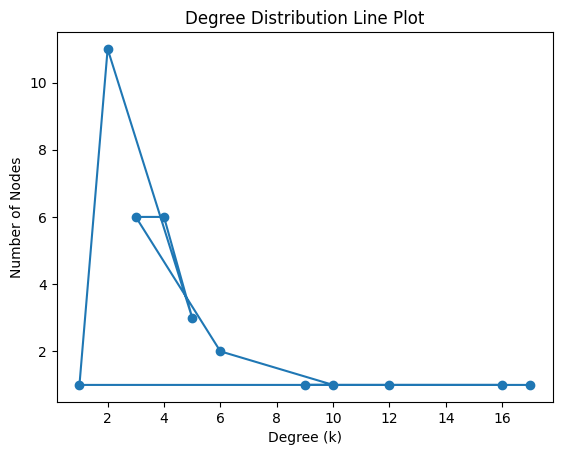

In [14]:
plt.figure()
plt.plot(k, v, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("Number of Nodes")
plt.title("Degree Distribution Line Plot")
plt.show()

**STEP 10: Zoomed Degree Distribution**

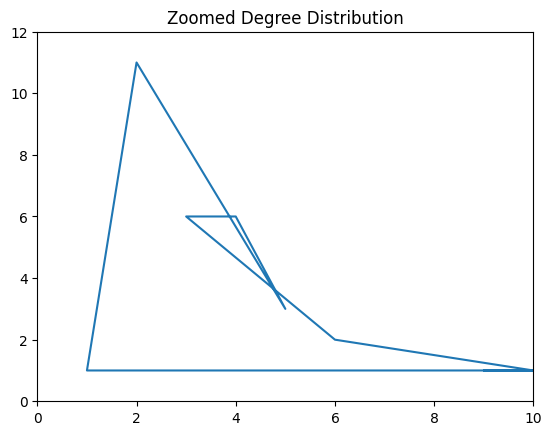

In [15]:
plt.figure()
plt.plot(k, v)
plt.xlim(0, 10)
plt.ylim(0, max(v)+1)
plt.title("Zoomed Degree Distribution")
plt.show()

**STEP 11: Network Density**

    Density Formula:
        D = 2E / (N(N-1))

In [16]:
N = G.number_of_nodes()
E = G.number_of_edges()
density = nx.density(G)
print("Density:", density)

Density: 0.13903743315508021


**STEP 12: Clustering Coefficient**

    Local clustering of node i:
        C_i = 2 * triangles / (k_i (k_i - 1))

In [17]:
clustering_dict = nx.clustering(G)
print("Clustering Dictionary:\n", clustering_dict)

# Average clustering coefficient
avg_clustering = nx.average_clustering(G)
print("Average Clustering Coefficient:", avg_clustering)

Clustering Dictionary:
 {0: 0.15, 1: 0.3333333333333333, 2: 0.24444444444444444, 3: 0.6666666666666666, 4: 0.6666666666666666, 5: 0.5, 6: 0.5, 7: 1.0, 8: 0.5, 9: 0, 10: 0.6666666666666666, 11: 0, 12: 1.0, 13: 0.6, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0, 19: 0.3333333333333333, 20: 1.0, 21: 1.0, 22: 1.0, 23: 0.4, 24: 0.3333333333333333, 25: 0.3333333333333333, 26: 1.0, 27: 0.16666666666666666, 28: 0.3333333333333333, 29: 0.6666666666666666, 30: 0.5, 31: 0.2, 32: 0.19696969696969696, 33: 0.11029411764705882}
Average Clustering Coefficient: 0.5706384782076823


**STEP 13: Diameter of Network**

    Diameter = max shortest path length

In [18]:
if nx.is_connected(G):
    diameter = nx.diameter(G)
    print("Diameter:", diameter)
else:
    print("Graph not connected - computing for largest component")
    largest_cc = max(nx.connected_components(G), key=len)
    subgraph = G.subgraph(largest_cc)
    diameter = nx.diameter(subgraph)
    print("Diameter of Largest Component:", diameter)

Diameter: 5


**STEP 14: Summary Statistics Function**

In [19]:
def network_summary(graph):
    print("Nodes:", graph.number_of_nodes())
    print("Edges:", graph.number_of_edges())
    print("Density:", nx.density(graph))
    print("Average Clustering:", nx.average_clustering(graph))
    if nx.is_connected(graph):
        print("Diameter:", nx.diameter(graph))
    else:
        print("Graph is not connected")

# Example
network_summary(G)

Nodes: 34
Edges: 78
Density: 0.13903743315508021
Average Clustering: 0.5706384782076823
Diameter: 5


**STEP 15: Centrality Measures**

In [20]:
# Betweenness Centrality
# C_B(v) = sum of (shortest paths through v / all shortest paths)
betweenness = nx.betweenness_centrality(G)
print("Betweenness Centrality:", betweenness)


# Closeness Centrality
# C_C(v) = 1 / (average shortest path length from v)
closeness = nx.closeness_centrality(G)
print("Closeness Centrality:", closeness)


# Eigenvector Centrality
# Measures influence of nodes
eigenvector = nx.eigenvector_centrality(G)
print("Eigenvector Centrality:", eigenvector)

Betweenness Centrality: {0: 0.43763528138528146, 1: 0.053936688311688304, 2: 0.14365680615680618, 3: 0.011909271284271283, 4: 0.0006313131313131313, 5: 0.02998737373737374, 6: 0.029987373737373736, 7: 0.0, 8: 0.05592682780182781, 9: 0.0008477633477633478, 10: 0.0006313131313131313, 11: 0.0, 12: 0.0, 13: 0.04586339586339586, 14: 0.0, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 0.03247504810004811, 20: 0.0, 21: 0.0, 22: 0.0, 23: 0.017613636363636363, 24: 0.0022095959595959595, 25: 0.0038404882154882154, 26: 0.0, 27: 0.02233345358345358, 28: 0.0017947330447330447, 29: 0.0029220779220779218, 30: 0.014411976911976909, 31: 0.13827561327561325, 32: 0.145247113997114, 33: 0.30407497594997596}
Closeness Centrality: {0: 0.5689655172413793, 1: 0.4852941176470588, 2: 0.559322033898305, 3: 0.4647887323943662, 4: 0.3793103448275862, 5: 0.38372093023255816, 6: 0.38372093023255816, 7: 0.44, 8: 0.515625, 9: 0.4342105263157895, 10: 0.3793103448275862, 11: 0.36666666666666664, 12: 0.3707865168539326, 13: 0.5

**STEP 16: Community Detection**

In [21]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community import louvain_communities


# ---- Girvan-Newman Algorithm ----
communities_gn = girvan_newman(G)
first_level = next(communities_gn)
print("Girvan-Newman Communities:", first_level)


# ---- Louvain Method ----
communities_louvain = louvain_communities(G)
print("Louvain Communities:", communities_louvain)

Girvan-Newman Communities: ({0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})
Louvain Communities: [{0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21}, {16, 4, 5, 6, 10}, {32, 33, 8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30}, {24, 25, 28, 31}]


**STEP 17: Power-Law Fitting of Degree Distribution**

    Power-law: P(k) ~ k^-alpha

Power-law Exponent (alpha): 0.5512494642283114


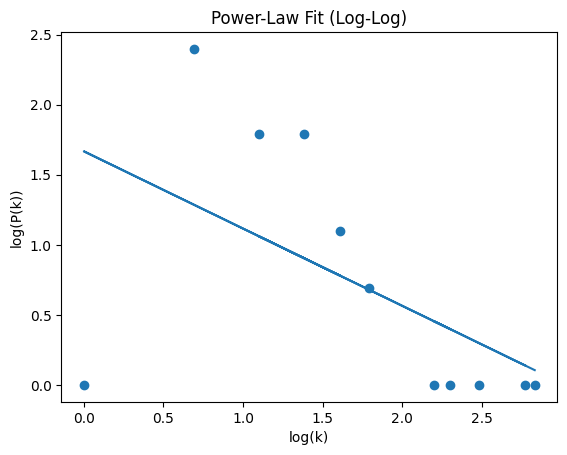

In [22]:
import numpy as np


# Convert degree counts to arrays
x = np.array(k)
y = np.array(v)


# Remove zero entries
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]


# Log-Log Transformation
log_x = np.log(x)
log_y = np.log(y)


# Linear Fit on log-log
alpha, intercept = np.polyfit(log_x, log_y, 1)
print("Power-law Exponent (alpha):", -alpha)


# Plot Power-Law Fit
plt.figure()
plt.scatter(log_x, log_y)
plt.plot(log_x, alpha*log_x + intercept)
plt.xlabel("log(k)")
plt.ylabel("log(P(k))")
plt.title("Power-Law Fit (Log-Log)")
plt.show()